In [1]:
import qewton

In [2]:
T = qewton.Variable("t", dim=1)
U = qewton.Variable("u", dim=1)

In [3]:
interval = qewton.geometries.Interval(T, 0, 2)

inner_sampler = qewton.GridSampler(interval, 1000)
left_sampler = qewton.GridSampler(interval.boundary_left, 1)

In [4]:
model = qewton.algorithms.FCN(
    in_neurons=T,
    hidden_neurons=10,
    out_neurons=U,
    n_hidden_layers=2,
    activation=qewton.bb.Tanh,
)

In [5]:
def residual_fun(u: U, t: T):  # type: ignore
    return u.gradient(t) - 2*t

constraint = qewton.PINNConstraint(residual_fun, name="PINNConstraint")
ode_graph = qewton.PINNPipeline(inner_sampler, [model], constraint)

In [6]:
def boundary_residual_fun(u: U):  # type: ignore
    return u

boundary_constraint = qewton.constraints.PINNConstraint(
    boundary_residual_fun, name="InitialConstraint"
)
boundary_graph = qewton.PINNPipeline(left_sampler, [model], boundary_constraint)

In [7]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=5000,
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=adam_phase,
    graphs=[boundary_graph, ode_graph],
    training_objectives=[boundary_constraint, constraint],
    device="cuda:0",
)

trainer.run()

Optimization Phase 1: 100%|██████████| 5000/5000 [00:21<00:00, 234.57it/s, loss=0.000253]


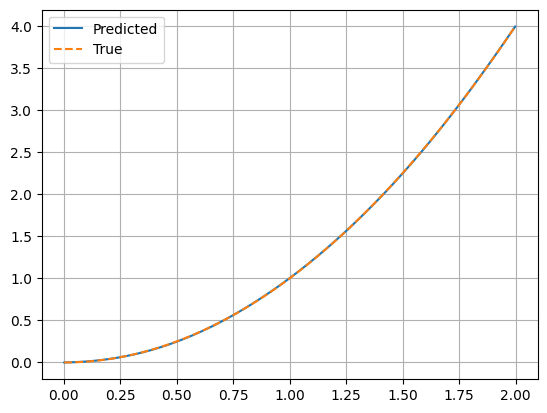

In [8]:
import matplotlib.pyplot as plt

inner_sampler.to("cpu")
model.to("cpu")

test_points = inner_sampler().detach()
u = model(test_points)

plt.plot(test_points, u.detach().numpy(), label="Predicted")
plt.plot(test_points, test_points ** 2, label="True", linestyle="dashed")
plt.legend()
plt.grid()